In [1]:
import pandas as pandas
import numpy as numpy
import matplotlib.pyplot as pyplot
import seaborn as seaborn

In [2]:
import warnings
warnings.filterwarnings("ignore")
seaborn.set(style="whitegrid")

In [3]:
dataframe= pandas.read_csv("Dataset.csv")

In [5]:
dataframe.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [6]:
dataframe.info(
)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [8]:
dataframe.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [10]:
dataframe["isFraud"].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [11]:
dataframe["isFlaggedFraud"].value_counts()

isFlaggedFraud
0    6362604
1         16
Name: count, dtype: int64

In [13]:
dataframe.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [14]:
dataframe.isnull().sum().sum()

np.int64(0)

In [6]:
round((dataframe["isFraud"].value_counts()[1] / dataframe.shape[0]) * 100,2)

np.float64(0.13)

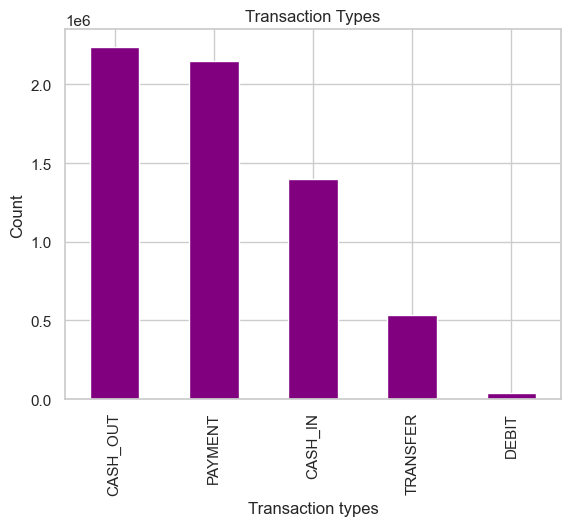

In [8]:
dataframe["type"].value_counts().plot(kind="bar" , title="Transaction Types" , color="purple")
pyplot.xlabel("Transaction types")
pyplot.ylabel("Count")
pyplot.show()

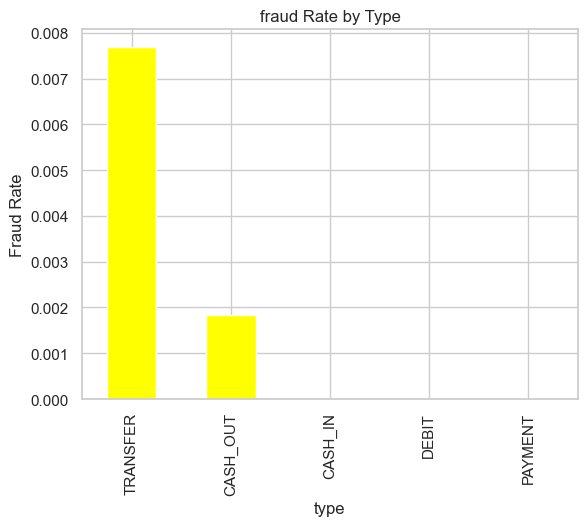

In [13]:
fraud_by_type = dataframe.groupby("type")["isFraud"].mean().sort_values(ascending= False)
fraud_by_type.plot(kind="bar" , title="fraud Rate by Type" , color="yellow")
pyplot.ylabel("Fraud Rate")
pyplot.show()

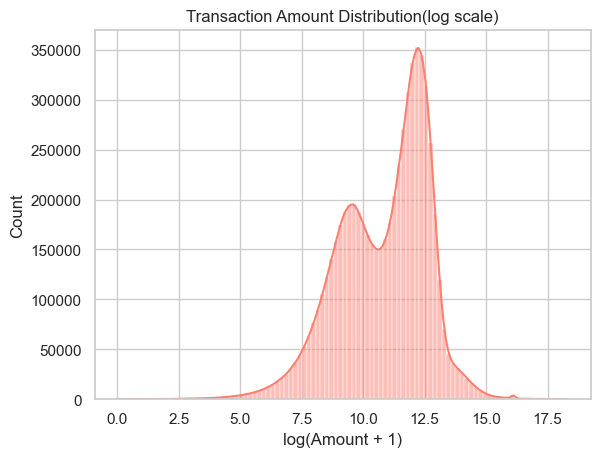

In [15]:
seaborn.histplot(numpy.log1p(dataframe["amount"]) , bins=100 , kde=True , color="salmon")
pyplot.title("Transaction Amount Distribution(log scale)")
pyplot.xlabel("log(Amount + 1)")
pyplot.show()

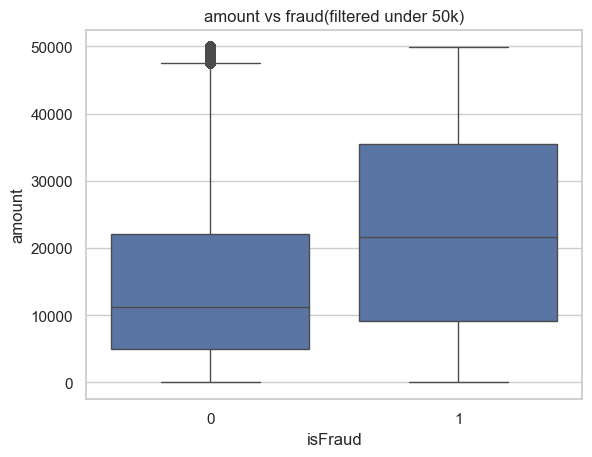

In [16]:
seaborn.boxplot(data= dataframe[dataframe["amount"] < 50000], x= "isFraud", y="amount")
pyplot.title("amount vs fraud(filtered under 50k)")
pyplot.show()

In [4]:
dataframe["balanceDiffOrig"] = dataframe["oldbalanceOrg"] - dataframe["newbalanceOrig"]
dataframe["balanceDiffDest"] = dataframe["oldbalanceDest"] - dataframe["newbalanceDest"]

In [5]:
(dataframe["balanceDiffOrig"] < 0).sum()

np.int64(1399253)

In [6]:
(dataframe["balanceDiffDest"] < 0).sum()

np.int64(2806464)

In [7]:
top_senders = dataframe["nameOrig"].value_counts().head(10)
top_senders

nameOrig
C1902386530    3
C363736674     3
C545315117     3
C724452879     3
C1784010646    3
C1677795071    3
C1462946854    3
C1999539787    3
C2098525306    3
C400299098     3
Name: count, dtype: int64

In [8]:
top_recievers = dataframe["nameDest"].value_counts().head(10)
top_recievers

nameDest
C1286084959    113
C985934102     109
C665576141     105
C2083562754    102
C248609774     101
C1590550415    101
C451111351      99
C1789550256     99
C1360767589     98
C1023714065     97
Name: count, dtype: int64

In [ ]:
fraud_users = dataframe[dataframe["isFraud"] == 1]["nameOrig"].value_counts().head(10)
fraud_users